In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
os.makedirs("plots", exist_ok=True)

In [5]:
df = pd.read_csv("car_data_cleaned.csv")
df.head()


,car_id,brand,model,manufacturing_year,fuel_type,transmission,engine_cc,max_power_bhp,mileage_kmpl,km_driven,location,car_price,car_age,price_per_cc,price_per_km
0,C001,Hyundai,i20,2018,Petrol,Manual,1200,83,18.6,45000,Bangalore,520000,7,433.333333,11.555556
1,C002,Maruti,Swift,2017,Petrol,Manual,1197,82,20.4,60000,Hyderabad,435000,8,363.408521,7.250000
2,C003,Toyota,Innova,2015,Diesel,Manual,2494,150,12.0,85000,Delhi,890000,10,356.856455,10.470588
3,C004,Honda,City,2019,Petrol,Automatic,1497,118,17.8,30000,Mumbai,960000,6,641.282565,32.000000
4,C005,Hyundai,Creta,2020,Diesel,Manual,1591,115,19.0,25000,Pune,1350000,5,848.522942,54.000000


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   car_id              49 non-null     object 
 1   brand               49 non-null     object 
 2   model               49 non-null     object 
 3   manufacturing_year  49 non-null     int64  
 4   fuel_type           49 non-null     object 
 5   transmission        49 non-null     object 
 6   engine_cc           49 non-null     int64  
 7   max_power_bhp       49 non-null     int64  
 8   mileage_kmpl        49 non-null     float64
 9   km_driven           49 non-null     int64  
 10  location            49 non-null     object 
 11  car_price           49 non-null     int64  
 12  car_age             49 non-null     int64  
 13  price_per_cc        49 non-null     float64
 14  price_per_km        49 non-null     float64
dtypes: float64(3), int64(6), object(6)
memory usage: 5.9+ KB


In [8]:
df.describe()

,manufacturing_year,engine_cc,max_power_bhp,mileage_kmpl,km_driven,car_price,car_age,price_per_cc,price_per_km
count,49.000000,49.000000,49.000000,49.000000,49.000000,4.900000e+01,49.000000,49.000000,49.000000
mean,2018.571429,1672.755102,125.530612,17.671429,41877.551020,1.327449e+06,6.428571,751.669586,50.528666
std,2.010390,482.705679,45.209283,2.893743,24721.475695,9.220534e+05,2.010390,377.479372,57.414852
min,2015.000000,998.000000,63.000000,11.000000,5000.000000,3.800000e+05,3.000000,257.629806,5.294118
25%,2017.000000,1461.000000,94.000000,16.000000,20000.000000,6.500000e+05,5.000000,433.911883,15.142857
50%,2019.000000,1498.000000,115.000000,17.500000,40000.000000,9.600000e+05,6.000000,667.222686,32.000000
75%,2020.000000,1991.000000,150.000000,19.200000,60000.000000,1.650000e+06,8.000000,1000.000000,58.181818
max,2022.000000,2995.000000,261.000000,24.400000,90000.000000,4.500000e+06,10.000000,2043.010753,300.000000


In [9]:
df.isna().sum()


car_id                0
brand                 0
model                 0
manufacturing_year    0
fuel_type             0
transmission          0
engine_cc             0
max_power_bhp         0
mileage_kmpl          0
km_driven             0
location              0
car_price             0
car_age               0
price_per_cc          0
price_per_km          0
dtype: int64

In [10]:
df.shape

(49, 15)

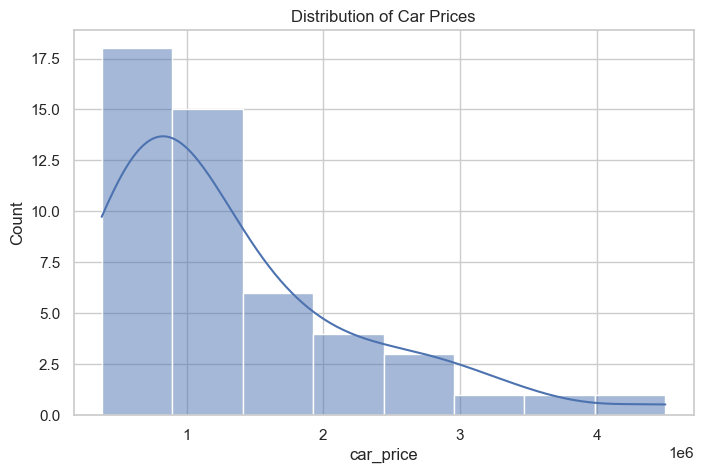

In [11]:
## Univariate Analysis
##Understanding distribution of individual features.
plt.figure(figsize=(8,5))
sns.histplot(df['car_price'], kde=True)
plt.title("Distribution of Car Prices")
plt.show()


In [ ]:
# Most cars are priced between 4–12 lakhs, with luxury cars forming a right tail.


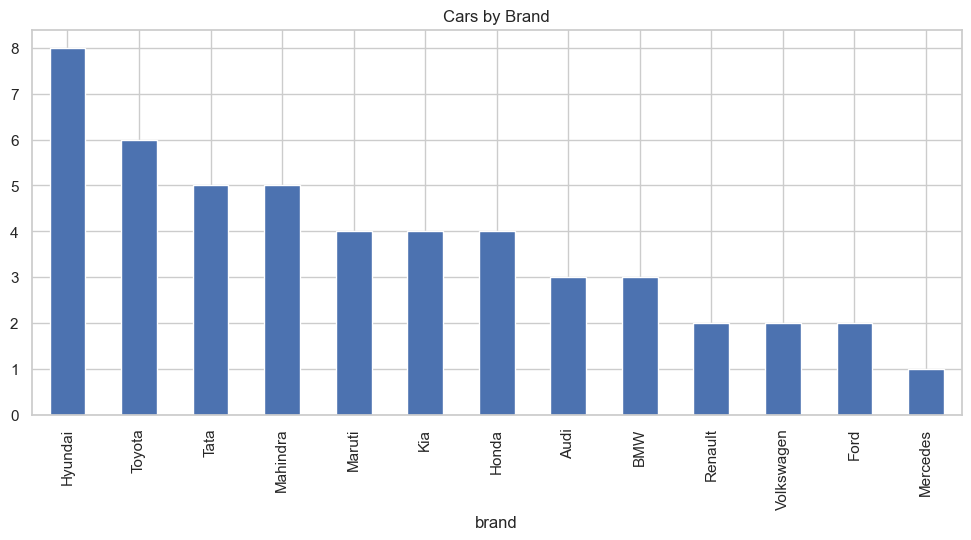

In [12]:
plt.figure(figsize=(12,5))
df['brand'].value_counts().plot(kind='bar')
plt.title("Cars by Brand")
plt.show()

#Hyundai, Maruti, Tata are the highest occurring brands in the dataset.



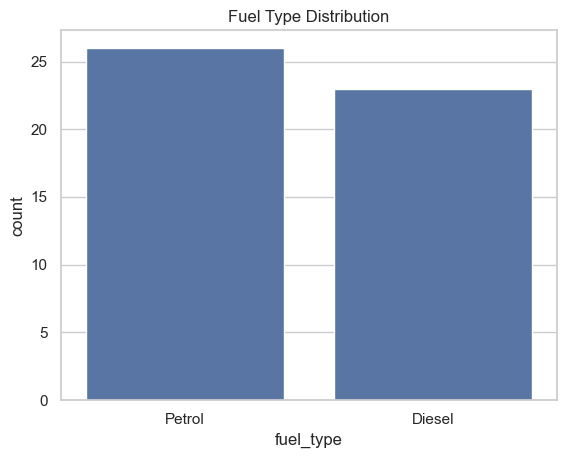

In [13]:
sns.countplot(data=df, x='fuel_type')
plt.title("Fuel Type Distribution")
plt.show()

#Petrol cars dominate the dataset compared to diesel.


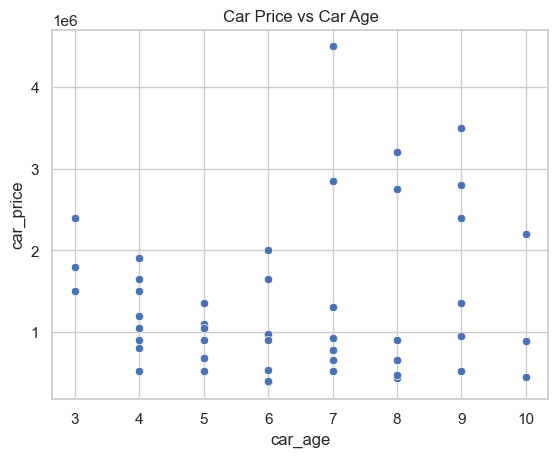

In [14]:
## Bivariate Analysis
# Understanding relationships between features.
sns.scatterplot(data=df, x='car_age', y='car_price')
plt.title("Car Price vs Car Age")
plt.show()



In [15]:
# Newer cars (age 0–5 years) have significantly higher prices.


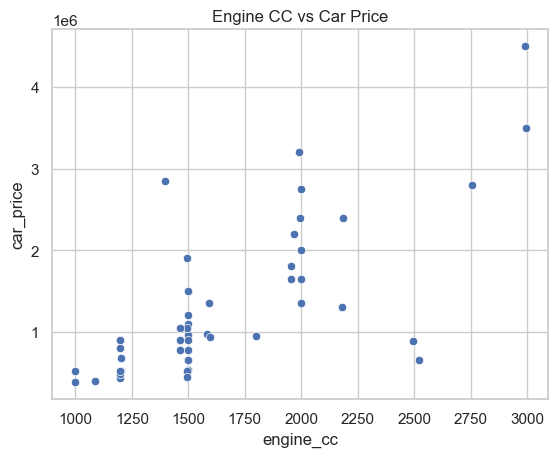

In [16]:
sns.scatterplot(data=df, x='engine_cc', y='car_price')
plt.title("Engine CC vs Car Price")
plt.show()
#Higher engine capacity strongly correlates with higher price.


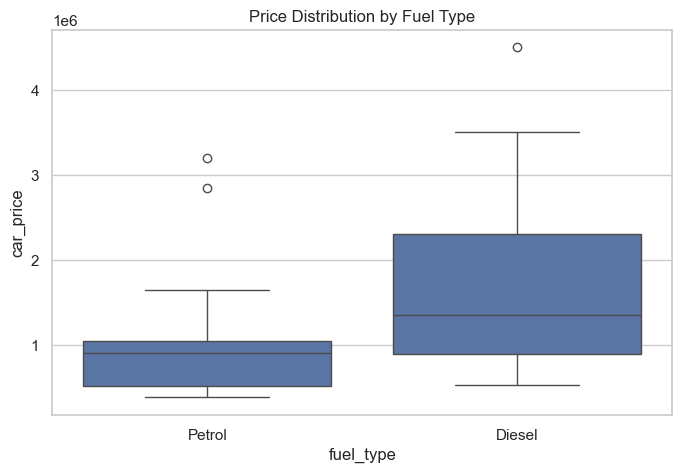

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='fuel_type', y='car_price')
plt.title("Price Distribution by Fuel Type")
plt.show()


In [18]:
# Diesel cars generally have higher prices.


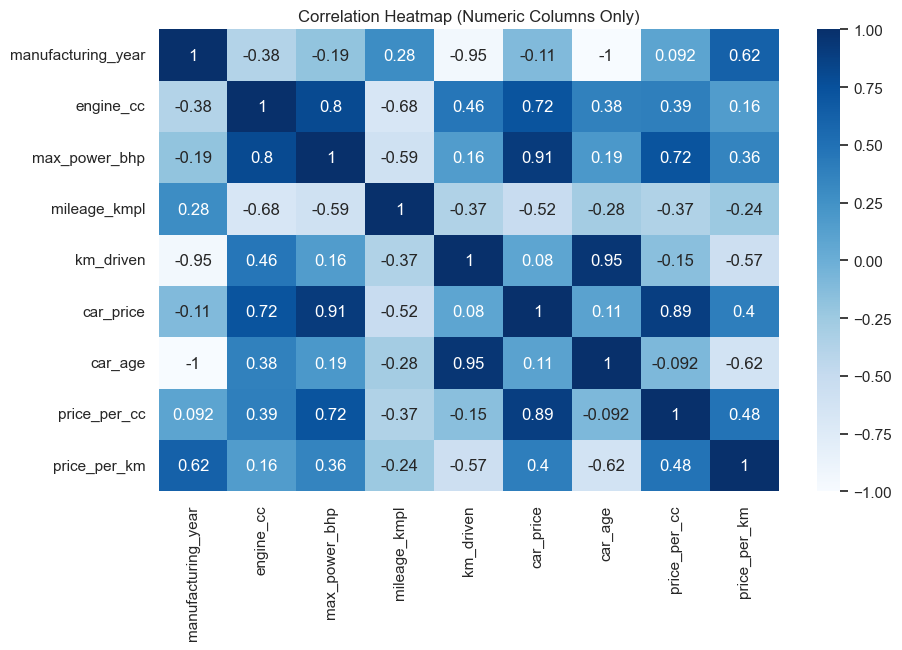

In [21]:
## Multivariate Analysis
# Correlation between numerical variables.


numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap (Numeric Columns Only)")
plt.show()

